In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('dataset/loanPayment.csv')
df.head()

,downpayment,principal,tenure,interest_rate,monthly_payment,prepayment(yr),total_payment
0,500000,1500000,6,7.6%,26500,0,2412500
1,500000,1500000,8,7.6%,21500,0,2560000
2,500000,1500000,10,7.6%,18500,0,2710000
3,500000,1500000,6,7.6%,26500,200000,2240000
4,500000,1500000,8,7.6%,21500,200000,2277000


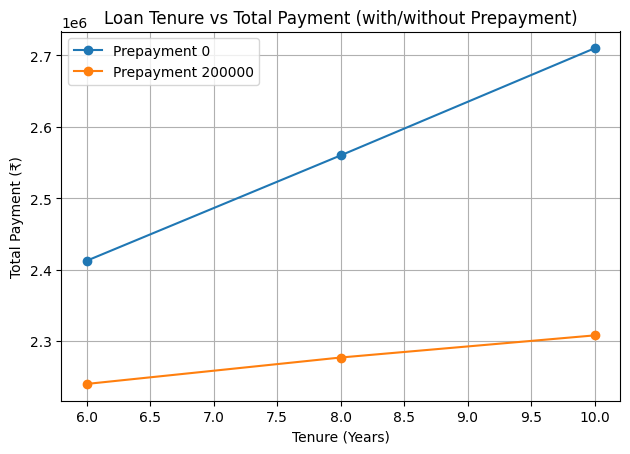

downpayment         500000
principal          1500000
tenure                   6
interest_rate         7.6%
monthly_payment      26500
prepayment(yr)      200000
total_payment      2240000
Name: 3, dtype: object

In [3]:
##Plot total payment vs tenure with prepayment and without
for prep in df["prepayment(yr)"].unique():
    subset = df[df["prepayment(yr)"] == prep]
    plt.plot(subset["tenure"], subset["total_payment"], marker='o', label=f"Prepayment {prep}")

plt.xlabel("Tenure (Years)")
plt.ylabel("Total Payment (₹)")
plt.title("Loan Tenure vs Total Payment (with/without Prepayment)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Find optimal option (minimum total payment)
optimal = df.loc[df["total_payment"].idxmin()]
optimal

In [4]:
# Calculate savings for each option compared to the corresponding option without prepayment
df['savings'] = 0
for i in range(3, 6):
    df.loc[i, 'savings'] = df.loc[i-3, 'total_payment'] - df.loc[i, 'total_payment']

# Display the dataframe with savings column
df[['tenure', 'prepayment(yr)', 'total_payment', 'savings']]

,tenure,prepayment(yr),total_payment,savings
0,6,0,2412500,0
1,8,0,2560000,0
2,10,0,2710000,0
3,6,200000,2240000,172500
4,8,200000,2277000,283000
5,10,200000,2308000,402000


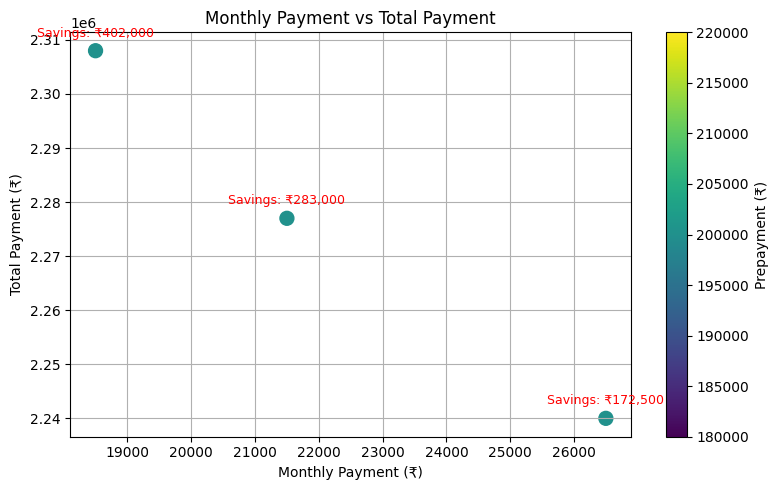

In [10]:
# Scatter plot of monthly payment vs total payment with prepayment

df_prepayment_only = df[df['prepayment(yr)'] > 0]
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    df_prepayment_only['monthly_payment'],
    df_prepayment_only['total_payment'],
    c=df_prepayment_only['prepayment(yr)'],
    cmap='viridis',
    s=100
)
plt.xlabel('Monthly Payment (₹)')
plt.ylabel('Total Payment (₹)')
plt.title('Monthly Payment vs Total Payment')
plt.colorbar(scatter, label='Prepayment (₹)')
plt.grid(True)

# Annotate savings for each prepayment option
for idx, row in df_prepayment_only.iterrows():
    plt.annotate(f"Savings: ₹{row['savings']:,}", (row['monthly_payment'], row['total_payment']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='red')

plt.tight_layout()
plt.show()
